<a href="https://colab.research.google.com/github/munnurumahesh03-coder/Swiggy-ETA-Predictor/blob/main/Swiggy_ETA_Prediction_LGBM_GPU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# GPU acceleration
import cudf         # GPU-accelerated dataframes
import cupy as cp       # GPU-accelerated arrays
from cuml.preprocessing import TargetEncoder  # GPU target encoding

# Standard ML
import lightgbm as lgb
from sklearn.model_selection import KFold,train_test_split

In [ ]:
import time
import warnings
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error,r2_score
from lightgbm import LGBMRegressor

from cuml.preprocessing import TargetEncoder as CuMLTargetEncoder

warnings.filterwarnings('ignore')

In [ ]:
print("\n" + "=" * 80)
print("Loading Data & Simulating Kaggle Split")
print("=" * 80)

# 1. Load the single Swiggy dataset
df = pd.read_csv(r'/content/swiggy_engineered_gold.csv')

# 2. Drop useless columns BEFORE we dynamically grab features
cols_to_drop = ['order_date', 'restaurant_longitude', 'delivery_longitude', 'restaurant_latitude', 'delivery_latitude', 'order_time_hour', 'order_day', 'order_month', 'is_weekend', 'pickup_time_minutes']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# 3. Simulate the Kaggle Train/Test Split
train_pd, test_pd = train_test_split(df, test_size=0.2, random_state=42)

# Reset index so our K-Fold loops don't crash later!
train_pd = train_pd.reset_index(drop=True)
test_pd = test_pd.reset_index(drop=True)

print(f'Train Shape: {train_pd.shape}')
print(f'Test Shape: {test_pd.shape}')

# 4. Define Target
TARGET = 'time_taken'

# 5. YOUR OPTIMIZED LOGIC: Dynamically grab features
BASE = [c for c in train_pd.columns if c not in ["id", TARGET]]
CATS = train_pd[BASE].select_dtypes(include=["object", "category"]).columns.tolist()
NUMS = train_pd[BASE].select_dtypes(include="number").columns.tolist()

print(f"Categorical Features ({len(CATS)}): {CATS}")
print(f"Numerical Features ({len(NUMS)}): {NUMS}")



Loading Data & Simulating Kaggle Split
Train Shape: (36401, 17)
Test Shape: (9101, 17)
Categorical Features (8): ['weather', 'traffic', 'type_of_vehicle', 'festival', 'city_type', 'city_name', 'order_day_of_week', 'order_time_of_day']
Numerical Features (8): ['age', 'ratings', 'vehicle_condition', 'multiple_deliveries', 'distance', 'delivery_bearing', 'order_hour_sin', 'order_hour_cos']


In [ ]:
print("\n" + "=" * 80)
print("Creating Smart Interaction Features")
print("=" * 80)

start_time = time.time()
INTER = []

# 1. CATEGORICAL INTERACTIONS (String Concatenation)

for col1, col2 in combinations(CATS, 2):
    new_col_name = f'{col1}_{col2}'
    INTER.append(new_col_name)
    for df in [train_pd, test_pd]:
        df[new_col_name] = df[col1].astype(str) + '_' + df[col2].astype(str)

# 2. NUMERICAL INTERACTIONS (Mathematical Ratios)
# We use domain knowledge to create powerful Swiggy-specific metrics
for df in [train_pd, test_pd]:
    # Density: How far is the rider traveling per order?
    df['delivery_density'] = df['distance'] / (df['multiple_deliveries'] + 1)

    # Efficiency: Age combined with Ratings
    df['rider_efficiency'] = df['age'] * df['ratings']

    # Vehicle Strain: Long distance on a bad vehicle = slower delivery
    # (Replaced expected_speed to avoid the pickup_time_minutes KeyError!)
    df['vehicle_strain'] = df['distance'] / (df['vehicle_condition'] + 1)

# Add our new math features to the NUMS list so they are tracked properly
NEW_NUMS = ['delivery_density', 'rider_efficiency', 'vehicle_strain']
NUMS.extend(NEW_NUMS)

elapsed = time.time() - start_time
print(f'✓ Created {len(INTER)} categorical interactions and {len(NEW_NUMS)} math features in {elapsed:.2f}s')



Creating Smart Interaction Features
✓ Created 28 categorical interactions and 3 math features in 0.48s


In [ ]:
import gc

print("\n" + "=" * 80)
print("Converting to cuDF for GPU Operations")
print("=" * 80)

convert_start = time.time()

# Move data from CPU RAM to GPU VRAM
train_cudf = cudf.DataFrame(train_pd)
test_cudf = cudf.DataFrame(test_pd)

# Clean up CPU memory to prevent crashes
gc.collect()

convert_time = time.time() - convert_start
print(f'✓ Converted to cuDF in {convert_time:.2f}s')



Converting to cuDF for GPU Operations
✓ Converted to cuDF in 1.01s


In [ ]:
print("\n" + "=" * 80)
print("Creating Leak-Proof Target Aggregations (GPU)")
print("=" * 80)

fe_start = time.time()

# 1. Include BOTH base categories and our new interaction features!
FEATURES_TO_AGGREGATE = CATS + INTER
AGG_FEATURES = []

# We need a copy of the training data in pandas for the CV split
train_pd_for_split = train_cudf.to_pandas()

# Set up the CV loop
N_CV_SPLITS = 5
kf = KFold(n_splits=N_CV_SPLITS, shuffle=True, random_state=42)

# Initialize new columns in our main cuDF dataframe with NaNs
for col in FEATURES_TO_AGGREGATE:
    train_cudf[f'TE_MEAN_{col}'] = cp.nan
    train_cudf[f'TE_STD_{col}'] = cp.nan
    AGG_FEATURES.extend([f'TE_MEAN_{col}', f'TE_STD_{col}'])

print(f"  Aggregating {len(FEATURES_TO_AGGREGATE)} features over {N_CV_SPLITS} folds...")

# --- Main CV Loop for Safe Aggregations ---
for fold, (train_idx, val_idx) in enumerate(kf.split(train_pd_for_split), 1):
    print(f"    Processing Fold {fold}/{N_CV_SPLITS}...")

    X_train_fold = train_cudf.iloc[train_idx]

    for col in FEATURES_TO_AGGREGATE:
        # Calculate mean and std ONLY on the training part of the fold
        agg_stats = X_train_fold.groupby(col)[TARGET].agg(['mean', 'std'])

        X_val_fold = train_cudf.iloc[val_idx]

        # Map the calculated stats to the validation part
        mean_map = X_val_fold[col].map(agg_stats['mean'])
        std_map = X_val_fold[col].map(agg_stats['std'])

        train_cudf[f'TE_MEAN_{col}'].iloc[val_idx] = mean_map
        train_cudf[f'TE_STD_{col}'].iloc[val_idx] = std_map

# --- Final Aggregations for the Test Set ---
print("\n  Calculating final aggregations for test set...")
for col in FEATURES_TO_AGGREGATE:
    agg_stats_full = train_cudf.groupby(col)[TARGET].agg(['mean', 'std'])

    test_cudf[f'TE_MEAN_{col}'] = test_cudf[col].map(agg_stats_full['mean'])
    test_cudf[f'TE_STD_{col}'] = test_cudf[col].map(agg_stats_full['std'])

# --- BUG FIX: Column-Specific Fill NaN ---
global_mean = train_cudf[TARGET].mean()
global_std = train_cudf[TARGET].std()

for col in FEATURES_TO_AGGREGATE:
    # Fill Mean with Mean, and STD with STD!
    train_cudf[f'TE_MEAN_{col}'] = train_cudf[f'TE_MEAN_{col}'].fillna(global_mean)
    train_cudf[f'TE_STD_{col}'] = train_cudf[f'TE_STD_{col}'].fillna(global_std)

    test_cudf[f'TE_MEAN_{col}'] = test_cudf[f'TE_MEAN_{col}'].fillna(global_mean)
    test_cudf[f'TE_STD_{col}'] = test_cudf[f'TE_STD_{col}'].fillna(global_std)

fe_time = time.time() - fe_start
print(f"\n✓ Created {len(AGG_FEATURES)} new aggregation features in {fe_time:.2f}s")



Creating Leak-Proof Target Aggregations (GPU)
  Aggregating 36 features over 5 folds...
    Processing Fold 1/5...
    Processing Fold 2/5...
    Processing Fold 3/5...
    Processing Fold 4/5...
    Processing Fold 5/5...

  Calculating final aggregations for test set...

✓ Created 72 new aggregation features in 7.96s


In [ ]:
# ==============================================================================
# FINAL STEP: Convert to Pandas & Dynamic Feature Selection
# ==============================================================================
import lightgbm as lgb
import matplotlib.pyplot as plt

# 1. Define Initial Features
FEATURES = NUMS + AGG_FEATURES

print("\n" + "=" * 80)
print("Converting back to pandas for Feature Selection")
print("=" * 80)
convert_back_start = time.time()

# Ensure all data is on the host (CPU) before converting
train = train_cudf.to_pandas()
test = test_cudf.to_pandas()

convert_back_time = time.time() - convert_back_start
print(f'✓ Converted back to pandas in {convert_back_time:.2f}s')

X_train_temp = train[FEATURES]
y_train_temp = train[TARGET]

# ==============================================================================
# THE "PROBE" MODEL: Finding the Top 99% Features
# ==============================================================================
print("\n" + "=" * 80)
print("Running Probe Model for Feature Selection (Top 99%)")
print("=" * 80)

# Train a fast baseline model to check feature importance
probe_model = lgb.LGBMRegressor(n_estimators=150, random_state=42, n_jobs=-1, verbose=-1)
probe_model.fit(X_train_temp, y_train_temp)

# Extract and sort feature importances
importances = probe_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Calculate Cumulative Importance (Percentage)
feature_imp_df['Cumulative_Importance'] = feature_imp_df['Importance'].cumsum() / feature_imp_df['Importance'].sum()

# Keep only features that make up the top 99% of importance
THRESHOLD = 0.99
top_features_df = feature_imp_df[feature_imp_df['Cumulative_Importance'] <= THRESHOLD]
FINAL_FEATURES = top_features_df['Feature'].tolist()

# Safety net: If the threshold is too strict and drops everything, keep at least the top 20
if len(FINAL_FEATURES) < 20:
    FINAL_FEATURES = feature_imp_df['Feature'].head(20).tolist()

dropped_count = len(FEATURES) - len(FINAL_FEATURES)

print(f"✓ Original Features: {len(FEATURES)}")
print(f"✓ Selected Features (Top 99%): {len(FINAL_FEATURES)}")
print(f"🗑️ Dropped Useless Features: {dropped_count}")

# Define final training and test sets using ONLY the selected features
X_train_final = train[FINAL_FEATURES]
y_train_final = train[TARGET]
X_test_final = test[FINAL_FEATURES]
y_test_final = test[TARGET]

print("\n✓ Data is now 100% numeric, optimized, and ready for Optuna!")
print(f"  - Final Training data shape: {X_train_final.shape}")
print(f"  - Final Testing data shape: {X_test_final.shape}")


Converting back to pandas for Feature Selection
✓ Converted back to pandas in 0.27s

Running Probe Model for Feature Selection (Top 99%)
✓ Original Features: 83
✓ Selected Features (Top 99%): 76
🗑️ Dropped Useless Features: 7

✓ Data is now 100% numeric, optimized, and ready for Optuna!
  - Final Training data shape: (36401, 76)
  - Final Testing data shape: (9101, 76)


In [ ]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 25.0 MB/s eta 0:00:00


In [ ]:
# ==============================================================================
# STEP: Optuna Hyperparameter Tuning (BUG-FREE UI VERSION)
# ==============================================================================
import optuna
import lightgbm as lgb

print("\n" + "=" * 80)
print("🚀 STARTING OPTUNA HYPERPARAMETER TUNING")
print("=" * 80)

def objective(trial):
    # 1. Define the Search Space
    param = {
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': 42,
        'n_estimators': 1000,

        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }

    # 2. Set up 3-Fold CV
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = []

    for train_idx, val_idx in kf.split(X_train_final):
        X_tr, X_va = X_train_final.iloc[train_idx], X_train_final.iloc[val_idx]
        y_tr, y_va = y_train_final.iloc[train_idx], y_train_final.iloc[val_idx]

        model = lgb.LGBMRegressor(**param)

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )

        preds = model.predict(X_va)
        rmse = np.sqrt(mean_squared_error(y_va, preds))
        cv_scores.append(rmse)

    return np.mean(cv_scores)

# --- THE FIX: Custom Callback for Safe Printing ---
def print_progress(study, trial):
    print(f"✅ Trial {trial.number + 1}/30 finished | RMSE: {trial.value:.4f} | Best so far: {study.best_value:.4f}")

# 3. Run the Optuna Study
study = optuna.create_study(direction='minimize', study_name="Swiggy_LGBM_Optimization")
optuna.logging.set_verbosity(optuna.logging.WARNING) # Hide default spam

print("Hunting for the best parameters... (Running 30 trials)\n")

# Run WITHOUT the buggy progress bar, using our safe callback instead
study.optimize(objective, n_trials=30, callbacks=[print_progress],show_progress_bar=True)

print("\n🏆 OPTUNA SEARCH COMPLETE 🏆")
print(f"Best CV RMSE: {study.best_value:.4f}")
print("Best Parameters:")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")



🚀 STARTING OPTUNA HYPERPARAMETER TUNING
Hunting for the best parameters... (Running 30 trials)



  0%|          | 0/30 [00:00<?, ?it/s]

✅ Trial 1/30 finished | RMSE: 3.9575 | Best so far: 3.9575
✅ Trial 2/30 finished | RMSE: 3.9459 | Best so far: 3.9459
✅ Trial 3/30 finished | RMSE: 3.9545 | Best so far: 3.9459
✅ Trial 4/30 finished | RMSE: 3.9322 | Best so far: 3.9322
✅ Trial 5/30 finished | RMSE: 3.9423 | Best so far: 3.9322
✅ Trial 6/30 finished | RMSE: 3.9352 | Best so far: 3.9322
✅ Trial 7/30 finished | RMSE: 3.9545 | Best so far: 3.9322
✅ Trial 8/30 finished | RMSE: 3.9745 | Best so far: 3.9322
✅ Trial 9/30 finished | RMSE: 4.0005 | Best so far: 3.9322
✅ Trial 10/30 finished | RMSE: 3.9596 | Best so far: 3.9322
✅ Trial 11/30 finished | RMSE: 3.9313 | Best so far: 3.9313
✅ Trial 12/30 finished | RMSE: 3.9319 | Best so far: 3.9313
✅ Trial 13/30 finished | RMSE: 3.9268 | Best so far: 3.9268
✅ Trial 14/30 finished | RMSE: 3.9288 | Best so far: 3.9268
✅ Trial 15/30 finished | RMSE: 3.9340 | Best so far: 3.9268
✅ Trial 16/30 finished | RMSE: 3.9338 | Best so far: 3.9268
✅ Trial 17/30 finished | RMSE: 3.9372 | Best so f

In [ ]:
N_SPLITS = 5

# Translated to LightGBM's language!
params = {
    'objective': 'regression',    # LightGBM's word for regression
    'metric': 'rmse',             # LightGBM's word for metric
    'num_leaves': 89,             # From Optuna
    'max_depth': 10,              # From Optuna
    'learning_rate': 0.02106903014741421, # From Optuna
    'min_child_samples': 20,      # From Optuna
    'subsample': 0.7991845400667572, # From Optuna
    'colsample_bytree': 0.7767437357092215, # From Optuna
    'n_estimators': 1000,         # Increased to 1000 because learning rate is low
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1                 # This silences LightGBM's annoying info logs!
}

print(f"\n{'=' * 80}")
print("LightGBM Configuration (Tuned Champion)")
print('=' * 80)
for k, v in params.items():
    print(f"  {k}: {v}")



LightGBM Configuration (Tuned Champion)
  objective: regression
  metric: rmse
  num_leaves: 89
  max_depth: 10
  learning_rate: 0.02106903014741421
  min_child_samples: 20
  subsample: 0.7991845400667572
  colsample_bytree: 0.7767437357092215
  n_estimators: 1000
  random_state: 42
  n_jobs: -1
  verbose: -1


In [ ]:

print("\n" + "=" * 80)
print("Starting Cross-Validation Training (LightGBM)")
print("=" * 80)

# 1. Initialize prediction arrays using our final datasets
oof_preds = np.zeros(len(X_train_final))
test_preds = np.zeros(len(X_test_final))

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

fold_scores = []
fold_times = []

# 2. The Clean, High-Speed Training Loop
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_final, y_train_final), 1):
    print(f'\n{"─" * 80}')
    print(f'Fold {fold}/{N_SPLITS}')
    print(f'{"─" * 80}')
    fold_start = time.time()

    # Split the data for this specific fold
    X_tr, X_va = X_train_final.iloc[train_idx], X_train_final.iloc[val_idx]
    y_tr, y_va = y_train_final.iloc[train_idx], y_train_final.iloc[val_idx]

    # ========================================================================
    # Train LightGBM Model
    # ========================================================================
    print("Training LightGBM...")
    model_start = time.time()

    # Instantiate our tuned champion
    model = lgb.LGBMRegressor(**params)

    # Fit the model with Early Stopping to prevent overfitting!
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    model_time = time.time() - model_start
    print(f'  ✓ Training completed in {model_time:.2f}s')

    # ========================================================================
    # Prediction and Evaluation
    # ========================================================================
    # Predict on the validation fold
    val_preds = model.predict(X_va)
    oof_preds[val_idx] = val_preds

    # Calculate RMSE for this fold
    mse = mean_squared_error(y_va, val_preds)
    fold_score = np.sqrt(mse)
    fold_scores.append(fold_score)

    # Calculate R2 Score for this fold
    fold_r2 = r2_score(y_va, val_preds)

    # Predict on the unseen test set and average it (Test Ensembling!)
    test_preds += model.predict(X_test_final) / N_SPLITS

    fold_time = time.time() - fold_start
    fold_times.append(fold_time)

    print(f'\n  Fold {fold} Results:')
    print(f'    RMSE: {fold_score:.4f}')
    print(f'    R² Score: {fold_r2:.4f}')
    print(f'    Time: {fold_time:.2f}s')



Starting Cross-Validation Training (LightGBM)

────────────────────────────────────────────────────────────────────────────────
Fold 1/5
────────────────────────────────────────────────────────────────────────────────
Training LightGBM...
  ✓ Training completed in 5.31s

  Fold 1 Results:
    RMSE: 3.8382
    R² Score: 0.8329
    Time: 5.69s

────────────────────────────────────────────────────────────────────────────────
Fold 2/5
────────────────────────────────────────────────────────────────────────────────
Training LightGBM...
  ✓ Training completed in 7.51s

  Fold 2 Results:
    RMSE: 3.9460
    R² Score: 0.8241
    Time: 7.94s

────────────────────────────────────────────────────────────────────────────────
Fold 3/5
────────────────────────────────────────────────────────────────────────────────
Training LightGBM...
  ✓ Training completed in 7.26s

  Fold 3 Results:
    RMSE: 3.9557
    R² Score: 0.8220
    Time: 7.58s

──────────────────────────────────────────────────────────

In [ ]:
from sklearn.metrics import r2_score

# 1. Calculate Overall Training (OOF) Score
overall_mse = mean_squared_error(y_train_final, oof_preds)
overall_rmse = np.sqrt(overall_mse)
overall_r2 = r2_score(y_train_final, oof_preds)

# 2. Calculate Unseen Test Set Score (The Ultimate Proof!)
test_mse = mean_squared_error(y_test_final, test_preds)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test_final, test_preds)

print('\n' + '=' * 80)
print('🏆 FINAL SWIGGY MODEL RESULTS 🏆')
print('=' * 80)
print(f'Overall OOF RMSE (Training): {overall_rmse:.4f} minutes')
print(f'Overall OOF R² Score:        {overall_r2:.4f}')
print('-' * 80)
print(f'🔥 UNSEEN TEST SET RMSE:     {test_rmse:.4f} minutes')
print(f'🔥 UNSEEN TEST SET R²:       {test_r2:.4f}')
print('-' * 80)
print(f'Mean Fold RMSE: {np.mean(fold_scores):.4f} (±{np.std(fold_scores):.4f})')
print(f'Total Training Time: {sum(fold_times):.2f}s')
print(f'Average Time per Fold: {np.mean(fold_times):.2f}s')
print('=' * 80)

print('\nFold Scores:')
for i, score in enumerate(fold_scores, 1):
    print(f'  Fold {i}: {score:.4f} ({fold_times[i - 1]:.2f}s)')



🏆 FINAL SWIGGY MODEL RESULTS 🏆
Overall OOF RMSE (Training): 3.9028 minutes
Overall OOF R² Score:        0.8272
--------------------------------------------------------------------------------
🔥 UNSEEN TEST SET RMSE:     3.9038 minutes
🔥 UNSEEN TEST SET R²:       0.8267
--------------------------------------------------------------------------------
Mean Fold RMSE: 3.9025 (±0.0449)
Total Training Time: 35.20s
Average Time per Fold: 7.04s

Fold Scores:
  Fold 1: 3.8382 (5.69s)
  Fold 2: 3.9460 (7.94s)
  Fold 3: 3.9557 (7.58s)
  Fold 4: 3.9056 (5.95s)
  Fold 5: 3.8673 (8.05s)


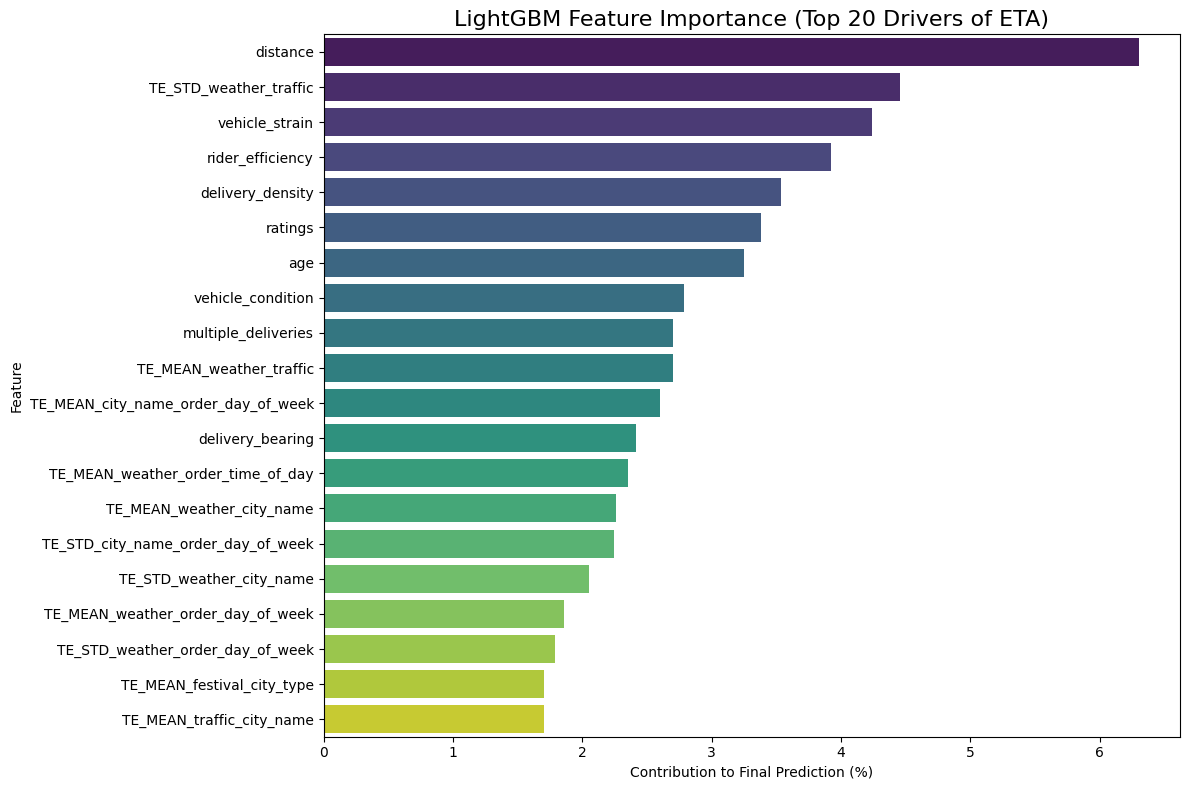

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Extract importances from our trained LightGBM model
importances = model.feature_importances_
feature_names = X_train_final.columns

# 2. Create a DataFrame and sort it
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Calculate the Percentage of total importance!
importance_df['Importance (%)'] = (importance_df['Importance'] / importance_df['Importance'].sum()) * 100

importance_df = importance_df.sort_values(by='Importance (%)', ascending=False).reset_index(drop=True)

# 3. Plot the Top Features (Using the new Percentage column)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance (%)', y='Feature', data=importance_df.head(20), palette='viridis')
plt.title('LightGBM Feature Importance (Top 20 Drivers of ETA)', fontsize=16)
plt.xlabel('Contribution to Final Prediction (%)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np

# 1. Extract raw importances from the trained LightGBM model
raw_importances = model.feature_importances_
feature_names = X_train_final.columns

# 2. Convert to Percentages (so they sum to 100%)
total_importance = raw_importances.sum()
importance_percentages = (raw_importances / total_importance) * 100

# 3. Create a DataFrame and sort it
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance (%)': importance_percentages
})
importance_df = importance_df.sort_values(by='Importance (%)', ascending=False).reset_index(drop=True)

# 4. Format for clean printing
importance_df_display = importance_df.copy()
importance_df_display['Importance (%)'] = importance_df_display['Importance (%)'].round(2).astype(str) + '%'

# 5. Print the results clearly
print("="*60)
print("🏆 TOP FEATURES (The Heavy Lifters)")
print("="*60)
print(importance_df_display.head(15).to_string(index=False))

print("\n" + "="*60)
print("🗑️ BOTTOM FEATURES (Candidates for Deletion)")
print("="*60)
print(importance_df_display.tail(10).to_string(index=False))


🏆 TOP FEATURES (The Heavy Lifters)
                            Feature Importance (%)
                           distance           6.3%
             TE_STD_weather_traffic          4.45%
                     vehicle_strain          4.24%
                   rider_efficiency          3.92%
                   delivery_density          3.54%
                            ratings          3.38%
                                age          3.25%
                  vehicle_condition          2.78%
                multiple_deliveries           2.7%
            TE_MEAN_weather_traffic           2.7%
TE_MEAN_city_name_order_day_of_week           2.6%
                   delivery_bearing          2.41%
  TE_MEAN_weather_order_time_of_day          2.35%
          TE_MEAN_weather_city_name          2.26%
 TE_STD_city_name_order_day_of_week          2.24%

🗑️ BOTTOM FEATURES (Candidates for Deletion)
                         Feature Importance (%)
TE_STD_type_of_vehicle_city_type          0.31%
       

In [ ]:
import joblib

print("Saving Kaggle Master Model and Encoding Rules...")

# 1. Train one final model on ALL the training data for maximum accuracy
final_model = LGBMRegressor(**params) # Or XGBRegressor if you kept XGBoost!
final_model.fit(X_train_final, y_train_final)
joblib.dump(final_model, 'swiggy_master_model.pkl')

# 2. Save the Target Encoding dictionaries (so Streamlit knows the math for "Stormy", etc.)
encoding_dicts = {}
for col in FEATURES_TO_AGGREGATE:
    # Calculate mean and std on the whole training data
    stats = train_pd.groupby(col)[TARGET].agg(['mean', 'std'])
    encoding_dicts[col] = stats.to_dict(orient='index')
joblib.dump(encoding_dicts, 'encoding_dicts.pkl')

# 3. Save the global fallbacks (in case a user types a brand new city)
global_stats = {'mean': train_pd[TARGET].mean(), 'std': train_pd[TARGET].std()}
joblib.dump(global_stats, 'global_stats.pkl')

# 4. Save the exact column order
joblib.dump(list(X_train_final.columns), 'master_columns.pkl')

print("✓ Success! Download the 4 .pkl files from the folder on the left.")


Saving Kaggle Master Model and Encoding Rules...
✓ Success! Download the 4 .pkl files from the folder on the left.


In [ ]:
%%writefile app.py
import gradio as gr
import pandas as pd
import numpy as np
import joblib
from itertools import combinations

# ==============================================================================
# 1. LOAD ARTIFACTS
# ==============================================================================
model = joblib.load('swiggy_master_model.pkl')
encoding_dicts = joblib.load('encoding_dicts.pkl')
global_stats = joblib.load('global_stats.pkl')
master_columns = joblib.load('master_columns.pkl')

# ==============================================================================
# 2. PREDICTION ENGINE
# ==============================================================================
def predict_eta(age, ratings, vehicle_condition, multiple_deliveries, type_of_vehicle,
                distance, delivery_bearing, order_time_hour, order_day_of_week, order_time_of_day,
                weather, traffic, city_type, city_name, festival):

    order_hour_sin = np.sin(2 * np.pi * order_time_hour / 24.0)
    order_hour_cos = np.cos(2 * np.pi * order_time_hour / 24.0)

    input_data = {
        'age': age, 'ratings': ratings, 'vehicle_condition': vehicle_condition,
        'multiple_deliveries': multiple_deliveries, 'distance': distance,
        'delivery_bearing': delivery_bearing, 'order_hour_sin': order_hour_sin,
        'order_hour_cos': order_hour_cos
    }

    input_data['delivery_density'] = distance / (multiple_deliveries + 1)
    input_data['rider_efficiency'] = age * ratings
    input_data['vehicle_strain'] = distance / (vehicle_condition + 1)

    CATS = ['weather', 'traffic', 'type_of_vehicle', 'festival', 'city_type', 'city_name', 'order_day_of_week', 'order_time_of_day']
    cat_values = {
        'weather': weather.lower(), 'traffic': traffic.lower(), 'type_of_vehicle': type_of_vehicle.lower(),
        'festival': festival.lower(), 'city_type': city_type.lower(), 'city_name': city_name.lower(),
        'order_day_of_week': order_day_of_week.lower(), 'order_time_of_day': order_time_of_day.lower()
    }

    INTER = []
    for col1, col2 in combinations(CATS, 2):
        new_col_name = f'{col1}_{col2}'
        INTER.append(new_col_name)
        cat_values[new_col_name] = f"{cat_values[col1]}_{cat_values[col2]}"

    FEATURES_TO_AGGREGATE = CATS + INTER
    for col in FEATURES_TO_AGGREGATE:
        category_string = cat_values[col]
        if col in encoding_dicts and category_string in encoding_dicts[col]:
            input_data[f'TE_MEAN_{col}'] = encoding_dicts[col][category_string]['mean']
            input_data[f'TE_STD_{col}'] = encoding_dicts[col][category_string]['std']
        else:
            input_data[f'TE_MEAN_{col}'] = global_stats['mean']
            input_data[f'TE_STD_{col}'] = global_stats['std']

    df_input = pd.DataFrame([input_data])
    df_final = df_input[master_columns]

    prediction = model.predict(df_final)[0]

    # Beautiful HTML output box
    return f"<div style='padding: 20px; border-radius: 10px; background-color: #e6f7ff; text-align: center; border: 2px solid #91d5ff;'><h2 style='color: #0050b3; margin: 0; font-size: 2em;'>{int(prediction)} mins</h2></div>"

# ==============================================================================
# 3. GRADIO UI (Clean Dashboard Layout)
# ==============================================================================
# Using the 'Base' theme removes the clumsy purple boxes!
with gr.Blocks(theme=gr.themes.Base()) as app:
    gr.Markdown("<h1 style='text-align: center;'>🍔 Swiggy Delivery ETA Predictor</h1>")
    gr.Markdown("<p style='text-align: center; color: gray;'>Adjust the delivery parameters below to calculate the exact estimated time of arrival.</p>")

    with gr.Row():
        # LEFT SIDE: Inputs hidden neatly inside Tabs
        with gr.Column(scale=2):
            with gr.Tab("🛵 Rider Details"):
                with gr.Row():
                    age = gr.Slider(18, 65, value=28, step=1, label="Rider Age")
                    ratings = gr.Slider(1.0, 5.0, value=4.5, step=0.1, label="Rider Rating")
                with gr.Row():
                    vehicle_condition = gr.Slider(0, 3, value=2, step=1, label="Vehicle Condition (0=Worst, 3=Best)")
                    multiple_deliveries = gr.Slider(0, 3, value=0, step=1, label="Multiple Deliveries")
                type_of_vehicle = gr.Dropdown(['motorcycle', 'scooter', 'electric_scooter', 'bicycle'], value='motorcycle', label="Vehicle Type")

            with gr.Tab("🌍 Order Details"):
                with gr.Row():
                    distance = gr.Slider(1.0, 30.0, value=5.0, step=0.1, label="Delivery Distance (km)")
                    delivery_bearing = gr.Slider(0, 360, value=90, step=1, label="Compass Direction (0=N, 90=E)")
                with gr.Row():
                    order_time_hour = gr.Slider(0, 23, value=19, step=1, label="Order Time (Hour of Day)")
                    order_day_of_week = gr.Dropdown(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], value='Friday', label="Day of Week")
                order_time_of_day = gr.Dropdown(['Morning', 'Afternoon', 'Evening', 'Night'], value='Evening', label="Time of Day")

            with gr.Tab("⛈️ Environment"):
                with gr.Row():
                    weather = gr.Dropdown(['Sunny', 'Cloudy', 'Fog', 'Windy', 'Stormy', 'Sandstorms'], value='Sunny', label="Weather")
                    traffic = gr.Dropdown(['Low', 'Medium', 'High', 'Jam'], value='Medium', label="Traffic Density")
                with gr.Row():
                    city_type = gr.Dropdown(['Urban', 'Metropolitian', 'Semi-Urban'], value='Metropolitian', label="City Type")
                    festival = gr.Dropdown(['No', 'Yes'], value='No', label="Is it a Festival?")
                city_name = gr.Textbox(value="Bangalore", label="City Name")

        # RIGHT SIDE: The Prediction Button and Result
        with gr.Column(scale=1):
            gr.Markdown("### 🚀 Get Real-Time ETA")
            predict_btn = gr.Button("Calculate ETA", variant="primary", size="lg")
            output_text = gr.HTML("<div style='padding: 20px; border-radius: 10px; background-color: #f0f0f0; text-align: center;'><h2 style='color: #888; margin: 0; font-size: 2em;'>-- mins</h2></div>")

    predict_btn.click(
        fn=predict_eta,
        inputs=[age, ratings, vehicle_condition, multiple_deliveries, type_of_vehicle,
                distance, delivery_bearing, order_time_hour, order_day_of_week, order_time_of_day,
                weather, traffic, city_type, city_name, festival],
        outputs=output_text
    )

# Removed share=True so it is perfectly configured for Hugging Face deployment
app.launch()


Overwriting app.py


In [ ]:
import pandas as pd
import numpy as np
import sklearn
import lightgbm as lgb
import joblib
import gradio as gr

print("🔍 EXACT VERSIONS USED FOR TRAINING & UI:")
print("-" * 40)
print(f"gradio=={gr.__version__}")
print(f"pandas=={pd.__version__}")
print(f"numpy=={np.__version__}")
print(f"scikit-learn=={sklearn.__version__}")
print(f"lightgbm=={lgb.__version__}")
print(f"joblib=={joblib.__version__}")


🔍 EXACT VERSIONS USED FOR TRAINING & UI:
----------------------------------------
gradio==6.20.0
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
lightgbm==4.6.0
joblib==1.5.3


In [ ]:
%%writefile requirements.txt
gradio==6.20.0
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
lightgbm==4.6.0
joblib==1.5.3

Overwriting requirements.txt
